# **Binary Model**

## Libraries

In [25]:
# Libraries
import sys
import os
import re
import random
import shutil

import pandas as pd
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score

from tensorflow.keras.preprocessing.image import load_img, img_to_array, smart_resize, ImageDataGenerator

from tensorflow.keras.applications.efficientnet import EfficientNetB0
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC

import optuna

sys.path.append('../src')  # Add root folder of project

from constants import DATA_DIR, IMAGE_DIR, IMAGE_SIZE_STANDARD

In [3]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [4]:
# Load the metadata
df = pd.read_csv(f'{DATA_DIR}/metadata.csv')

# Load the IsAnimal data
label = pd.read_csv(f'{DATA_DIR}/binary_labels.csv')

# Join the two dataframes
data = pd.merge(
    df
    ,label
    ,left_on='rare_species_id'
    ,right_on='image_id'
    ,how='inner'
).drop(columns=['rare_species_id', 'image_id'])

In [5]:
# # Creating a sample
# train_df, sample_df = train_test_split(
#     data,
#     test_size=0.3,
#     stratify=data['family'],
#     random_state=20
# )

## Data Preprocessing

In [6]:
# Performing the splits
train_df, test_df = train_test_split(data, test_size=0.2, stratify=data['family'], random_state=20)  # Create test set
train_df, val_df = train_test_split(train_df, test_size=0.15, stratify=train_df['family'], random_state=20)  # Create validation set

In [7]:
# Encoding the target
enc = LabelEncoder()

train_df['family'] = enc.fit_transform(train_df['family'])
val_df['family'] = enc.transform(val_df['family'])
test_df['family'] = enc.transform(test_df['family'])

In [8]:
# Image resizing target dimensions
IMG_SIZE = 224
BATCH_SIZE = 8

In [9]:
# Defining functions to resize the images
# def smart_resize_img(file_path, target_size=(IMG_SIZE, IMG_SIZE)):
#     img = load_img(f'{IMAGE_DIR}/{file_path}')  # Load image
#     img_array = img_to_array(img)  # Convert to array
#     resized_img = smart_resize(img_array, target_size)  # Resize image
#     resized_img /= 255.0
    
#     return resized_img

def smart_resize_img(image, target_size=(IMG_SIZE, IMG_SIZE)):
    resized_img = smart_resize(image, target_size)  # Resize image
    resized_img /= 255.0  # Normalize the image
    
    return resized_img

# Custom generator that uses smart_resize
# def smart_resize_generator(dataframe, target, batch_size=BATCH_SIZE, target_size=(IMG_SIZE, IMG_SIZE)):
#     while True:
#         # Iterate through the dataframe in batches
#         for i in range(0, len(dataframe), batch_size):
#             batch_df = dataframe.iloc[i:i+batch_size]
            
#             # Prepare the batch of images and labels
#             batch_images = np.array([smart_resize_img(file_path, target_size) for file_path in batch_df['file_path']])
#             batch_labels = np.array(batch_df[target])
            
#             yield batch_images, batch_labels

In [10]:
# # Resizing the images
# label_train_generator = smart_resize_generator(train_df, 'label', batch_size=BATCH_SIZE, target_size=(IMG_SIZE, IMG_SIZE))
# print('train resizing completed')
# label_val_generator = smart_resize_generator(val_df, 'label', batch_size=BATCH_SIZE, target_size=(IMG_SIZE, IMG_SIZE))
# print('validation resizing completed')
# label_test_generator = smart_resize_generator(test_df, 'label', batch_size=BATCH_SIZE, target_size=(IMG_SIZE, IMG_SIZE))
# print('test resizing completed')

In [11]:
# # Transformation functions
# def rotate_right(img): return img.rotate(-90, expand=True)
# def rotate_left(img): return img.rotate(90, expand=True)
# def flip_horizontal(img): return ImageOps.mirror(img)
# def shear(img):
#     shear_transform = transforms.RandomAffine(degrees=0, shear=20)
#     return shear_transform(img)
# def zoom(img):
#     zoom_transform = transforms.RandomAffine(degrees=0, scale=(0.8, 1.5))
#     return zoom_transform(img)


# transformations = {
#     "rotate_right": rotate_right,
#     "rotate_left": rotate_left,
#     "flip": flip_horizontal,
#     # "shear": shear,
#     # "zoom": zoom
# }

# def augment_images(df, output_dir, target_per_class):
#     os.makedirs(output_dir, exist_ok=True)
#     class_counts = df['label'].value_counts()
#     max_count = class_counts.max()

#     # Identify minority classes
#     minority_classes = class_counts[class_counts < max_count].index

#     # List to hold new rows for augmented images
#     augmented_rows = []

#     for label in minority_classes:
#         class_df = df[df['label'] == label]
#         num_to_generate = target_per_class

#         if num_to_generate <= 0:
#             continue

#         label_dir = os.path.join(output_dir, str(label))
#         os.makedirs(label_dir, exist_ok=True)

#         for _ in range(num_to_generate):
#             row = class_df.sample(1).iloc[0]
#             img_path = row['file_path']
#             original_name = img_path[:-4]
#             ext = img_path[-4:]

#             try:
#                 img = Image.open(f'{IMAGE_DIR}/{img_path}')  # .convert('RGB')
#             except Exception as e:
#                 print(f"Error loading {img_path}: {e}")
#                 continue

#             # Apply random transformation
#             transform_name, transform_fn = random.choice(list(transformations.items()))
#             new_img = transform_fn(img)
#             new_filename = f"{original_name}_{transform_name}{ext}"
#             new_img_path = new_filename
#             new_img.save(f'{IMAGE_DIR}/{new_filename}')

#             # Create a new row for the augmented image and append it to augmented_rows
#             new_row = row.copy()
#             new_row['file_path'] = new_img_path  # Update the file path to the new image
#             augmented_rows.append(new_row)

#     # Add augmented rows to the original dataframe
#     augmented_df = pd.DataFrame(augmented_rows)
#     updated_df = pd.concat([df, augmented_df], ignore_index=True)

#     return updated_df

In [ ]:
# # Clean created images
# for filename in os.listdir(IMAGE_DIR):
#     # Check if there's any letter in the filename
#     if re.search(r'[a-zA-Z]', filename[:-4]):
#         file_path = os.path.join(IMAGE_DIR, filename)
#         if os.path.isfile(file_path):
#             os.remove(file_path)
#             print(f"Deleted: {file_path}")

In [ ]:
# updated_df = augment_images(train_df, output_dir=IMAGE_DIR, target_per_class=6500)

In [33]:
import math

def show_augmented_images(generator, num_images=10):
    images, labels = next(generator)

    actual_num = min(num_images, len(images))  # Avoid index errors

    max_cols = 4
    rows = math.ceil(actual_num / max_cols)
    plt.figure(figsize=(max_cols * 3, rows * 3))

    for i in range(actual_num):
        plt.subplot(rows, max_cols, i + 1)
        plt.imshow(images[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=90,
    shear_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    channel_shift_range=30.0,
    zoom_range=(0.8, 1.2),
    preprocessing_function=smart_resize_img
)
test_datagen = ImageDataGenerator(preprocessing_function=smart_resize_img)

# Train generator
binary_train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=f'{IMAGE_DIR}',
    x_col='file_path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=True  # shuffle for training
)

# Validation generator
binary_val_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=f'{IMAGE_DIR}',
    x_col='file_path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

# Test generator
binary_test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=f'{IMAGE_DIR}',
    x_col='file_path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

Found 8148 validated image filenames.
Found 1439 validated image filenames.
Found 2397 validated image filenames.


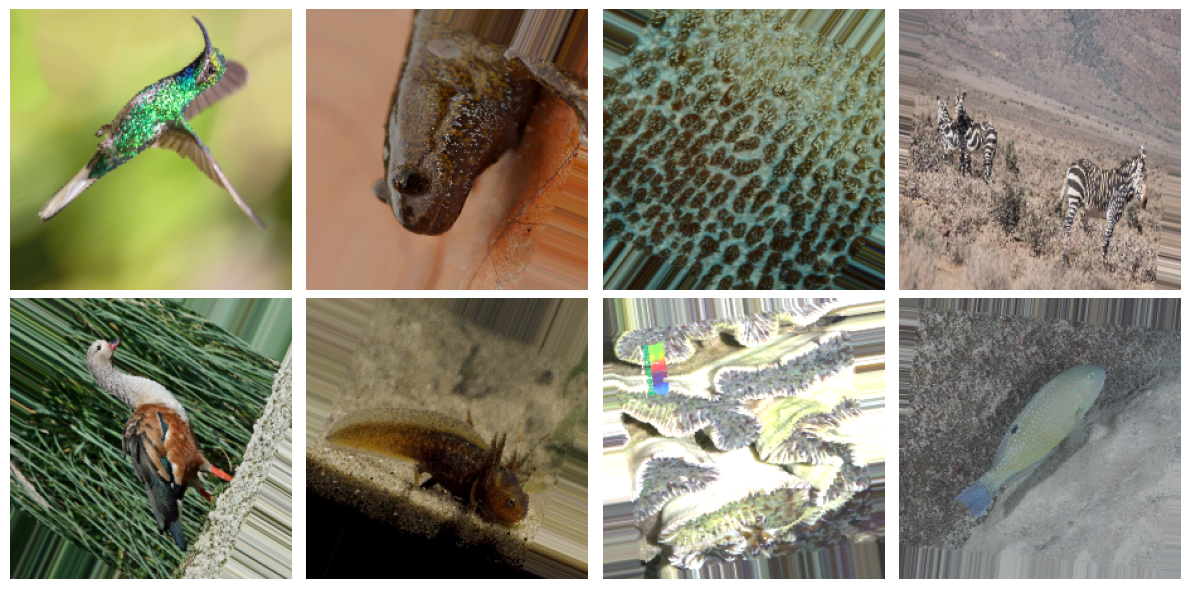

In [34]:
show_augmented_images(binary_train_generator, num_images=10)

## Modelling

In [14]:
# def objective(trial):
#     """
#     Objective function for Optuna hyperparameter optimization.
    
#     Args:
#     - trial (optuna.trial.Trial): The trial object used to sample hyperparameters.
    
#     Returns:
#     - float: The evaluation metric (validation accuracy or other).
#     """
#     lr = trial.suggest_float("lr", 1e-6, 1e-1)
#     optimizer_type = trial.suggest_categorical("optimizer", ["adam", "sgd"])
#     patience = trial.suggest_int("patience", 1, 3)
#     lr_factor = trial.suggest_float("lr_factor", 0.1, 0.7)
#     lr_patience = trial.suggest_int("lr_patience", 1, 5)

#     # Set the input
#     input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

#     # Load the pre-trained model
#     base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=input_tensor)

#     # Add necessary layers
#     x = GlobalAveragePooling2D()(base_model.output)
#     output = Dense(1, activation='sigmoid')(x)  # Binary classification

#     binary_model = Model(inputs=input_tensor, outputs=output)

#     # Optimizer setup based on dynamic 'optimizer_type'
#     if optimizer_type == "adam":
#         optimizer = Adam(learning_rate=lr)
#     elif optimizer_type == "sgd":
#         optimizer = SGD(learning_rate=lr)
#     else:
#         raise ValueError(f"Unknown optimizer type: {optimizer_type}")
    
#     # Compiling the model
#     binary_model.compile(
#         optimizer=optimizer,
#         loss='binary_crossentropy',
#         metrics=['accuracy', 'precision', 'recall']
#     )

#     # Fit the model
#     binary_model.fit(
#         binary_train_generator,
#         validation_data=binary_val_generator,
#         epochs=5,
#         steps_per_epoch=int(np.ceil(len(train_df) / BATCH_SIZE)),
#         callbacks=[
#             EarlyStopping(patience=patience, restore_best_weights=True),
#             ReduceLROnPlateau(patience=lr_patience, factor=lr_factor, verbose=1)
#         ],
#         verbose=1
#     )

#     # Evaluate the model using the  validation set
#     _, val_accuracy, _, _ = binary_model.evaluate(binary_val_generator, verbose=0)
    
#     # Return the validation accuracy as the objective metric
#     return val_accuracy

In [15]:
# # Create a study
# study = optuna.create_study(direction="maximize")

# # Optimize the objective function
# study.optimize(lambda trial: objective(trial), n_trials=3)

# # Get the best trial's hyperparameters
# print(f"Best trial: {study.best_trial.params}")

In [16]:
# Build the model

# Set the input
input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Load the pre-trained model
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=input_tensor)

# Add necessary layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)  # Binary classification

binary_model = Model(inputs=input_tensor, outputs=output)

I0000 00:00:1744834057.159311   34937 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1744834057.344083   34937 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1744834057.345058   34937 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1744834057.347514   34937 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [17]:
# Compiling the model
binary_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(), 'precision', 'recall']
)

In [18]:
# Fit the model
binary_model.fit(
    binary_train_generator,
    validation_data=binary_val_generator,
    epochs=5,
    steps_per_epoch=int(np.ceil(len(train_df) / BATCH_SIZE)),
    callbacks=[
        EarlyStopping(patience=3, restore_best_weights=True),
        ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
    ],
    verbose=1
)

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1744834101.888869   35012 service.cc:146] XLA service 0x7f9fac003370 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744834101.888897   35012 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX350, Compute Capability 6.1
2025-04-16 21:08:23.147757: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-16 21:08:27.753615: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90100
E0000 00:00:1744834126.960994   35012 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1744834127.167670   35012 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0

 475/1019 ━━━━━━━━━━━━━━━━━━━━ 5:30 607ms/step - accuracy: 0.8686 - auc: 0.4989 - loss: 0.3935 - precision: 0.9249 - recall: 0.9323

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


 999/1019 ━━━━━━━━━━━━━━━━━━━━ 12s 605ms/step - accuracy: 0.8918 - auc: 0.5049 - loss: 0.3538 - precision: 0.9271 - recall: 0.9579

E0000 00:00:1744834783.821147   35015 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1744834784.015659   35015 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1744834784.863727   35015 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1744834785.061279   35015 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-04-16 21:20:13.516681: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion', 32 bytes spill 

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 851s 740ms/step - accuracy: 0.8923 - auc: 0.5050 - loss: 0.3528 - precision: 0.9271 - recall: 0.9585 - val_accuracy: 0.0709 - val_auc: 0.5000 - val_loss: 483.8916 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0100
Epoch 2/5
1019/1019 ━━━━━━━━━━━━━━━━━━━━ 593s 582ms/step - accuracy: 0.9254 - auc: 0.5408 - loss: 0.2774 - precision: 0.9277 - recall: 0.9974 - val_accuracy: 0.0709 - val_auc: 0.4514 - val_loss: 7.9441 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0100
Epoch 3/5
1019/1019 ━━━━━━━━━━━━━━━━━━━━ 581s 570ms/step - accuracy: 0.9310 - auc: 0.5724 - loss: 0.2557 - precision: 0.9321 - recall: 0.9988 - val_accuracy: 0.9090 - val_auc: 0.6227 - val_loss: 0.3006 - val_precision: 0.9389 - val_recall: 0.9648 - learning_rate: 0.0100
Epoch 4/5
1019/1019 ━━━━━━━━━━━━━━━━━━━━ 583s 572ms/step - accuracy: 0.9293 - auc: 0.6421 - loss: 0.2499 - precision: 0.9297 - recall: 0.9995 - val_accuracy: 0.0709 - val_auc: 0.3

In [19]:
# # Export the model
# binary_model.save('../models/binary_model.keras')

In [20]:
# # Load the model
# binary_model = load_model('../models/binary_model.keras')

In [21]:
# Make predictions
predictions = binary_model.predict(
    binary_test_generator
    ,steps=len(binary_test_generator)
    ,verbose=1
)

300/300 ━━━━━━━━━━━━━━━━━━━━ 132s 420ms/step


In [22]:
# Get the true labels
y_true = binary_test_generator.labels

# Convert predictions to class labels
y_pred = (predictions > 0.5).astype(int).flatten()

# Calculate metrics
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")

Accuracy: 0.9328
Precision: 0.9328
Recall: 1.0000


In [23]:
# Get unique values and their counts
unique, counts = np.unique(y_pred, return_counts=True)

# Display the result
value_counts = dict(zip(unique, counts))
print(value_counts)

{1: 2397}


In [24]:
# # Save the predictions
# file_paths = binary_test_generator.filenames
# pred_df = pd.DataFrame({
#     'file_path': file_paths,
#     'predictions': (predictions > 0.5).astype(int).flatten()
# })

# # Export to csv
# # pred_df.to_csv('../models/binary_predictions.csv', index=False)